### Best practise

In [18]:
import pandas as pd
df=pd.read_csv('all_kindle_review.csv')
df.head()

,Unnamed: 0.1,Unnamed: 0,asin,helpful,rating,reviewText,reviewTime,reviewerID,reviewerName,summary,unixReviewTime
0,0,11539,B0033UV8HI,"[8, 10]",3,"Jace Rankin may be short, but he's nothing to ...","09 2, 2010",A3HHXRELK8BHQG,Ridley,Entertaining But Average,1283385600
1,1,5957,B002HJV4DE,"[1, 1]",5,Great short read. I didn't want to put it dow...,"10 8, 2013",A2RGNZ0TRF578I,Holly Butler,Terrific menage scenes!,1381190400
2,2,9146,B002ZG96I4,"[0, 0]",3,I'll start by saying this is the first of four...,"04 11, 2014",A3S0H2HV6U1I7F,Merissa,Snapdragon Alley,1397174400
3,3,7038,B002QHWOEU,"[1, 3]",3,Aggie is Angela Lansbury who carries pocketboo...,"07 5, 2014",AC4OQW3GZ919J,Cleargrace,very light murder cozy,1404518400
4,4,1776,B001A06VJ8,"[0, 1]",4,I did not expect this type of book to be in li...,"12 31, 2012",A3C9V987IQHOQD,Rjostler,Book,1356912000


In [19]:
##most import features here is review text and rating other will be getting ignored here

df=df[['reviewText','rating']]

In [20]:
data.head()

,reviewText,rating
0,"Jace Rankin may be short, but he's nothing to ...",3
1,Great short read. I didn't want to put it dow...,5
2,I'll start by saying this is the first of four...,3
3,Aggie is Angela Lansbury who carries pocketboo...,3
4,I did not expect this type of book to be in li...,4


In [21]:
df.shape

(12000, 2)

In [22]:
df.isnull().sum()

reviewText    0
rating        0
dtype: int64

In [23]:
df['rating'].unique()

array([3, 5, 4, 2, 1])

In [24]:
df['rating'].value_counts()


rating
5    3000
4    3000
3    2000
2    2000
1    2000
Name: count, dtype: int64

In [26]:
##preprocessing and cleaning
##positive review is 1 anad negative review is 0
df['rating']=df['rating'].apply(lambda x:0 if x<3 else 1)

In [27]:
df['rating']

0        1
1        1
2        1
3        1
4        1
        ..
11995    1
11996    1
11997    1
11998    0
11999    1
Name: rating, Length: 12000, dtype: int64

In [28]:
df['rating'].unique()

array([1, 0])

In [30]:
df['rating'].value_counts()

rating
1    8000
0    4000
Name: count, dtype: int64

In [33]:
## 1.lower all the cases

df['reviewText'].str.lower()

0        jace rankin may be short, but he's nothing to ...
1        great short read.  i didn't want to put it dow...
2        i'll start by saying this is the first of four...
3        aggie is angela lansbury who carries pocketboo...
4        i did not expect this type of book to be in li...
                               ...                        
11995    valentine cupid is a vampire- jena and ian ano...
11996    i have read all seven books in this series. ap...
11997    this book really just wasn't my cuppa.  the si...
11998    tried to use it to charge my kindle, it didn't...
11999    taking instruction is a look into the often hi...
Name: reviewText, Length: 12000, dtype: str

In [34]:
df.head()

,reviewText,rating
0,"Jace Rankin may be short, but he's nothing to ...",1
1,Great short read. I didn't want to put it dow...,1
2,I'll start by saying this is the first of four...,1
3,Aggie is Angela Lansbury who carries pocketboo...,1
4,I did not expect this type of book to be in li...,1


In [46]:
#removing special characters
df['reviewText'] = df['reviewText'].astype(str).str.replace(
    r'[^a-zA-Z0-9\s]', '', regex=True
)

#removing stopwords
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))

df['reviewText'] = df['reviewText'].apply(
    lambda x: " ".join([word for word in x.split() if word not in stop_words])
)

#removing urls
import re

df['reviewText'] = df['reviewText'].apply(
    lambda x: re.sub(r'http\S+|www\S+|https\S+', '', x)
)

#removing html tags
from bs4 import BeautifulSoup

df['reviewText'] = df['reviewText'].apply(
    lambda x: BeautifulSoup(x, 'html.parser').get_text()
)

#removing extra spaces
df['reviewText'] = df['reviewText'].str.replace(
    r'\s+',
    ' ',
    regex=True
).str.strip()

In [47]:
df.head()

,reviewText,rating
0,Jace Rankin may short nothing mess man hauled ...,1
1,Great short read I want put I read one sitting...,1
2,Ill start saying first four books I expecting ...,1
3,Aggie Angela Lansbury carries pocketbooks inst...,1
4,I expect type book library pleased find price ...,1


In [45]:
print(stop_words)

{'such', 'mightn', 'by', "that'll", 'off', 'under', 'wouldn', 'some', 'nor', 'yours', 'theirs', 'be', "aren't", "they've", 'being', 'and', 'shan', "they're", "won't", 'did', 'each', 'has', "mightn't", 'in', 'll', 'doesn', 'while', "needn't", 'again', 'herself', 'from', 'same', "we'd", 'm', 'is', 'ours', 'where', 'through', "we'll", 'when', 'of', "you've", 'this', 'ourselves', 'having', 'your', 'once', 'what', "hadn't", "doesn't", 'between', 'we', "it'll", "don't", 'or', "it'd", "he's", 'aren', 'because', 'were', 't', 'my', 'own', 'against', 'hadn', 'her', "should've", 'whom', 'had', 'how', 'most', 'there', "she'll", 'been', 'them', "they'll", 'it', "i'd", 'yourself', 'here', 'itself', 'd', 'ain', 'have', 'his', 'out', 'do', 'our', "wasn't", 'you', "shouldn't", 'himself', 'at', 're', "couldn't", 'i', 'don', "you'll", 'down', 'who', "he'll", 'hasn', 'they', 'him', 'before', 'he', 'o', "it's", "i'll", 'themselves', 'should', "weren't", 'on', 'during', 'than', 'into', "she's", "we're", 'a'

In [50]:
##lemmatizing
from nltk.stem import WordNetLemmatizer
lemmatizer=WordNetLemmatizer()

df['reviewText'] = df['reviewText'].apply(
    lambda x: " ".join(
        lemmatizer.lemmatize(word)
        for word in x.split()
    )
)

In [51]:
df.head()

,reviewText,rating
0,Jace Rankin may short nothing mess man hauled ...,1
1,Great short read I want put I read one sitting...,1
2,Ill start saying first four book I expecting c...,1
3,Aggie Angela Lansbury carry pocketbook instead...,1
4,I expect type book library pleased find price ...,1


In [55]:
##train_test_split

from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(df['reviewText'],df['rating'],test_size=0.2)

In [57]:
##bow,word2vec,nltk,tfidf
from sklearn.feature_extraction.text import CountVectorizer
bow=CountVectorizer()
X_train_bow=bow.fit_transform(X_train).toarrray()
X_test_bow=bow.transform(X_test).toarray()

In [59]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf=TfidfVectorizer()
X_train_tfidf=tfidf.fit_transform(X_train).toarray()
X_test_tfidf=tfidf.transform(X_test).toarray()

In [64]:
X_train_bow

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 451227 stored elements and shape (9600, 38230)>

In [65]:
X_test_bow

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 110013 stored elements and shape (2400, 38230)>

In [71]:
from sklearn.naive_bayes import GaussianNB
nb_model_bow=GaussianNB().fit(X_train_bow.toarray(),y_train)
nb_model_tfidf=GaussianNB().fit(X_train_tfidf.toarray(),y_train)

MemoryError: Unable to allocate 2.73 GiB for an array with shape (9600, 38230) and data type float64

In [72]:
from sklearn.naive_bayes import MultinomialNB

nb_model_bow = MultinomialNB()
nb_model_bow.fit(X_train_bow, y_train)

nb_model_tfidf = MultinomialNB()
nb_model_tfidf.fit(X_train_tfidf, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [74]:
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score

In [76]:
y_pred_bow=nb_model_bow.predict(X_test_bow)
y_pred_tfidf=nb_model_tfidf.predict(X_test_tfidf)

In [79]:
print("Bow_Accuracy:",accuracy_score(y_test,y_pred_bow))

Bow_Accuracy: 0.8391666666666666


In [80]:
confusion_matrix(y_test,y_pred_bow)

array([[ 602,  230],
       [ 156, 1412]])

In [83]:
print("tfidf_Accuracy:",accuracy_score(y_test,y_pred_tfidf))

tfidf_Accuracy: 0.6795833333333333


In [85]:
confusion_matrix(y_test,y_pred_tfidf)

array([[  65,  767],
       [   2, 1566]])

### Custom Review Analysis

In [86]:
review = ["This movie was absolutely fantastic and I loved it"]

review_bow = bow.transform(review)

prediction = nb_model_bow.predict(review_bow)

print(prediction)

[1]


In [89]:
user_review = input("Enter a review: ")

review_bow = bow.transform([user_review])

prediction = nb_model_bow.predict(review_bow)

if prediction[0] == 1:
    print("Positive Sentiment 😊")
else:
    print("Negative Sentiment 😞")

Enter a review:  waste of money


Negative Sentiment 😞


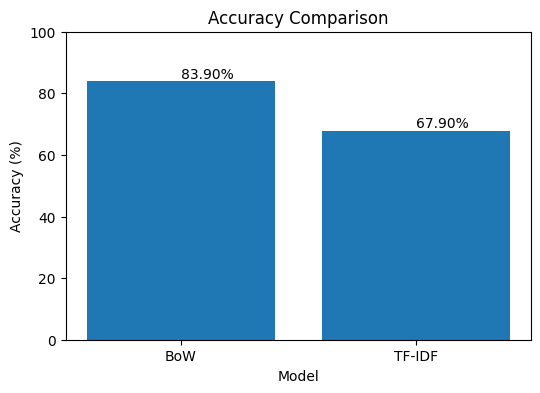

In [90]:
import matplotlib.pyplot as plt

models = ['BoW', 'TF-IDF']
accuracy = [83.9,67.9] 
plt.figure(figsize=(6,4))
plt.bar(models, accuracy)

plt.title('Accuracy Comparison')
plt.xlabel('Model')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 100)

for i, v in enumerate(accuracy):
    plt.text(i, v + 1, f'{v:.2f}%')

plt.show()

#### CONCLUSION

This project implemented sentiment analysis using Bag of Words (BoW) and TF-IDF feature extraction techniques with a Multinomial Naive Bayes classifier. The BoW model achieved an accuracy of approximately 83.9%, while the TF-IDF model achieved approximately 67.9%. Based on the results, BoW performed better for this dataset. The project demonstrates the effectiveness of NLP techniques in classifying text sentiments and provides a foundation for exploring more advanced methods in the future.